In [1]:
%load_ext autoreload
%autoreload 2
from typing import Literal
import torch
import torch.nn as nn   
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import sys
from csbdeep.utils import normalize
from scipy.ndimage import uniform_filter1d
from freq2clean import Freq2Clean
sys.path.append("..")
from src import *

/home/vmorelli-iit.local/Projects/freq2clean/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cupy Available= 1


In [2]:
denoiser_name: Literal["deepcad", "noise2noise", "noise2void"] = "deepcad"
denoiser_variant = "_150"
dataset = "synthetic"
CUPY_AVAILABLE = False
PATCH_T = 600
AVG_WIN = 2024
BATCH_SIZE = 1
METRICS_PATH = Path(f"f2c_{dataset}_metrics_{denoiser_name}.csv")
RES_DIR = mkdir(f"results/{dataset}/")
MAX_FRAMES = 1800
device = "cuda"
snapdir = mkdir("snapshots")
checkpointdir = mkdir("snapshots/checkpoints")

In [3]:
x = Recording(f"dataset/{dataset}/x.tif", max_frames=MAX_FRAMES).normalized
y_ = Recording(f"dataset/{dataset}/{denoiser_name}{denoiser_variant}.tif", max_frames=MAX_FRAMES).normalized
gt_ = Recording(f"dataset/{dataset}/gt.tif", max_frames=MAX_FRAMES).normalized
x_bar = uniform_filter1d(x, size=AVG_WIN, axis=0, mode="reflect")

In [4]:
overlap = 0.0
new_patcht = PATCH_T * (1 - overlap)
if overlap == 0:
    n = x.shape[0] // PATCH_T
    idx = (np.arange(n)[:, None] * PATCH_T + np.arange(PATCH_T)).astype(int)
else:
    discard = math.ceil(1 / (1 - overlap) - 1)
    n = int(x.shape[0] // new_patcht)
    idx = (np.arange(n)[:-discard, None] * new_patcht + np.arange(PATCH_T)).astype(int)

x = torch.from_numpy(x[idx]).float()
x_bar = torch.from_numpy(x_bar[idx]).float()
y = torch.from_numpy(y_[idx]).float()
gt = torch.from_numpy(gt_[idx]).float()
testset = TensorDataset(x, x_bar, y, gt)
dataloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)
del x, x_bar  # , y_, gt_
cprint(f"Testset has", len(idx), "samples.")

Testset has 3 samples.


In [5]:
ckpt = sorted(checkpointdir.glob("*.pt"), key=lambda file: int(file.stem))[-1]
cprint("cyan:Loading checkpoint", ckpt.stem)
model = Freq2Clean(frames=PATCH_T)
# model.alphas = nn.Parameter(torch.tensor([0.85] + [0.00] * (model.frames // 2)))
model.to(device)
model.load_state_dict(torch.load(ckpt, map_location=device))
model.eval()

# Test
f2cs = []
with torch.no_grad():
    for x, x_bar, y, gt in tqdm(dataloader):
        out = model(y.to(device), x_bar.to(device))
        f2cs.append(out.cpu())

f2cs = torch.cat(f2cs, dim=0)
f2c = f2cs.reshape(-1, f2cs.shape[2], f2cs.shape[3]).numpy()

Loading checkpoint 69


100%|██████████| 3/3 [00:01<00:00,  2.30it/s]


In [6]:
ssim3d(f2c, gt_, step=4), ssim3d(y_, gt_, step=4),

(0.86061692237854, 0.7620623111724854)

ssim3d improves, yet the video loses temporal info

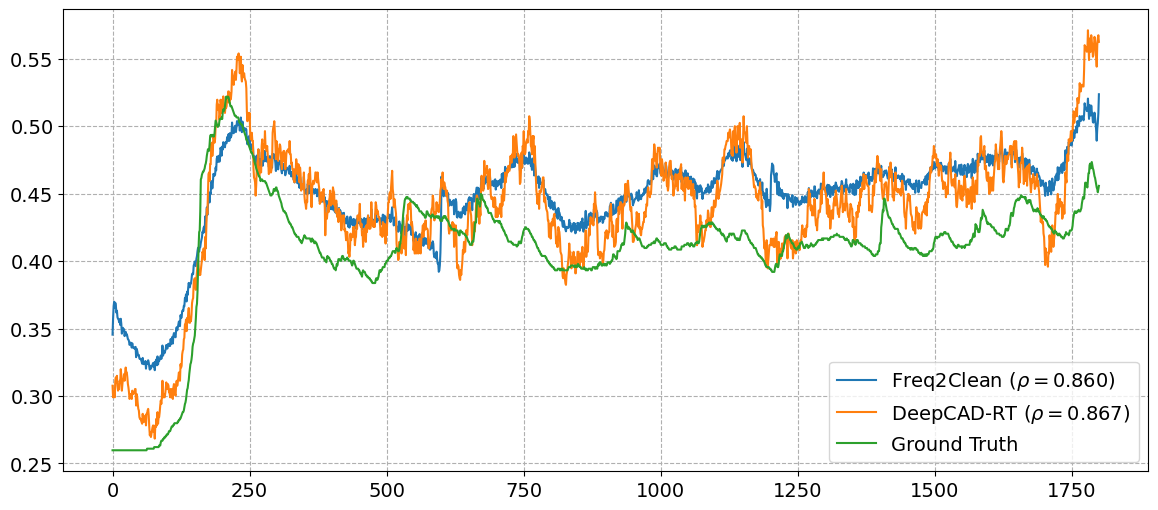

In [7]:
coord = random.randrange(490), random.randrange(490)
f2c_s = pd.Series(f2c[:, coord[0], coord[1]])
y_s = pd.Series(y_[:, coord[0], coord[1]])
gt_s = pd.Series(gt_[:, coord[0], coord[1]])
ax = f2c_s.plot(label=f"Freq2Clean ($\\rho={f2c_s.corr(gt_s):.3f}$)", figsize=(14, 6))
y_s.plot(ax=ax, label=f"DeepCAD-RT ($\\rho={y_s.corr(gt_s):.3f}$)")
gt_s.plot(ax=ax, label="Ground Truth")
plt.legend()

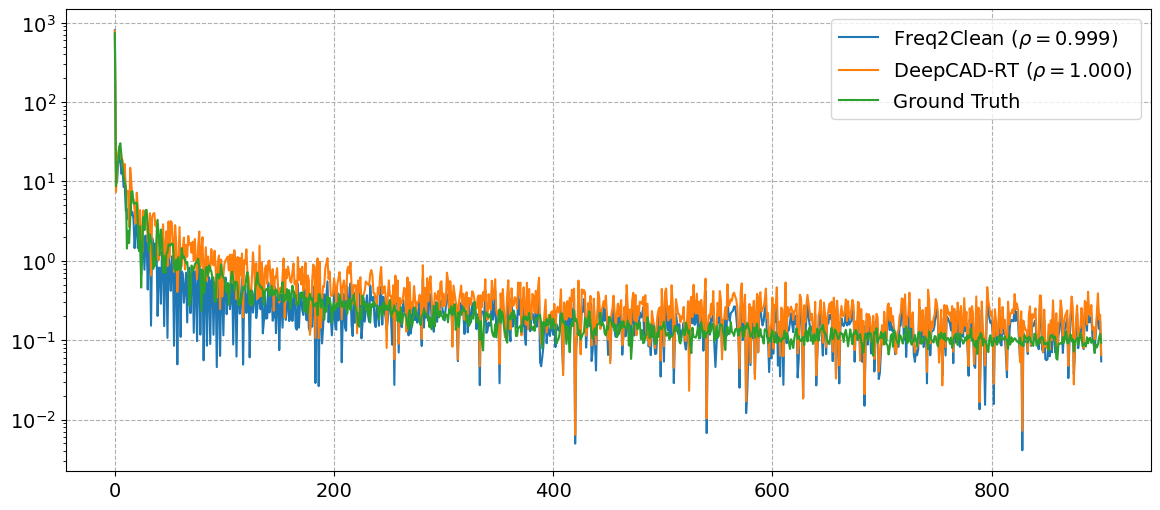

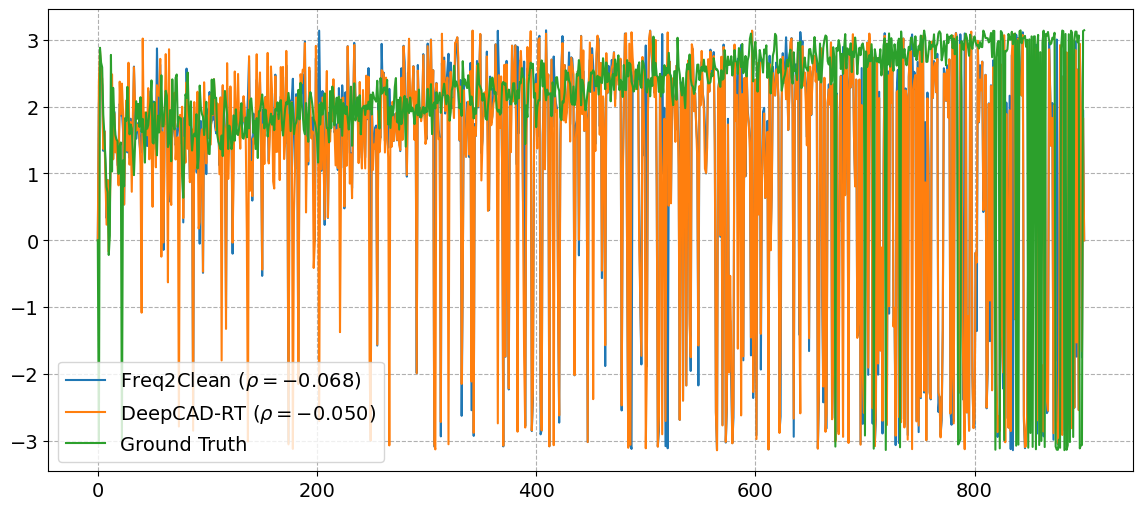

In [8]:
f2c_s = pd.Series(np.abs(np.fft.rfft(f2c[:, coord[0], coord[1]])))
y_s = pd.Series(np.abs(np.fft.rfft(y_[:, coord[0], coord[1]])))
gt_s = pd.Series(np.abs(np.fft.rfft(gt_[:, coord[0], coord[1]])))
ax = f2c_s.plot(label=f"Freq2Clean ($\\rho={f2c_s.corr(gt_s):.3f}$)", figsize=(14, 6))
y_s.plot(ax=ax, label=f"DeepCAD-RT ($\\rho={y_s.corr(gt_s):.3f}$)")
gt_s.plot(ax=ax, label="Ground Truth")
plt.legend()
plt.yscale("log")
plt.show()
f2c_s = pd.Series(np.angle(np.fft.rfft(f2c[:, coord[0], coord[1]])))
y_s = pd.Series(np.angle(np.fft.rfft(y_[:, coord[0], coord[1]])))
gt_s = pd.Series(np.angle(np.fft.rfft(gt_[:, coord[0], coord[1]])))
ax = f2c_s.plot(label=f"Freq2Clean ($\\rho={f2c_s.corr(gt_s):.3f}$)", figsize=(14, 6))
y_s.plot(ax=ax, label=f"DeepCAD-RT ($\\rho={y_s.corr(gt_s):.3f}$)")
gt_s.plot(ax=ax, label="Ground Truth")
plt.legend()

In [10]:
Recording(f2c).render("f2c_150_l1+l2.mp4", normalize=False)
# Recording(y_).render("y_150.mp4", normalize=False)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (490, 490) to (496, 496) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
x265 [info]: HEVC encoder version 3.5+1-f0c1022b6
x265 [info]: build info [Linux][GCC 8.3.0][64 bit] 8bit+10bit+12bit
x265 [info]: using cpu capabilities: MMX2 SSE2Fast LZCNT SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2
x265 [info]: Main profile, Level-3 (Main tier)
x265 [info]: Thread pool created using 24 threads
x265 [info]: Slices                              : 1
x265 [info]: frame threads / pool features       : 4 / wpp(8 rows)
x265 [warning]: Source height < 720p; disabling lookahead-slices
x265 [info]: Coding QT: max CU size, min CU size : 64 / 8
x265 [info]: Residual QT: max TU size, max depth : 32 / 1 inter / 1 intra
x265 [info]: ME / range / subpel / merge         : hex / 57